Ingest and clean cart level data from Vori. This report was extracted from the UI Reports > Item Sales > Underlying data

In [1]:
import pandas as pd
import numpy as numpy
import os
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
os.getcwd()

'/Users/casita/Documents/gitdev/merchAnalysis/cart_analysis'

In [3]:
df = pd.read_csv('./Items with cost(2).csv')

/var/folders/7x/md6t50l11gnfjmmrc6f2f7lr0000gn/T/ipykernel_15607/1483129609.py:1: DtypeWarning: Columns (0: Barcode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./Items with cost(2).csv')


In [4]:
#42 columns is a lot
df.shape

(73951, 42)

In [4]:
#print only the float columns
df.select_dtypes(include=['float64']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73951 entries, 0 to 73950
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   % Items with cost     73951 non-null  float64
 1   Shopper Phone         45 non-null     float64
 2   Product ID            73951 non-null  float64
 3   Each Cost             69752 non-null  float64
 4   Retail Price          73951 non-null  float64
 5   Wic Adjusted Price    0 non-null      float64
 6   Quantity              73951 non-null  float64
 7   Weight                25814 non-null  float64
 8   Promotion Amount      73951 non-null  float64
 9   Items Total           73951 non-null  float64
 10  Bottle Deposits       73951 non-null  float64
 11  Discount and Rewards  73951 non-null  float64
 12  Wic Adjustment        0 non-null      float64
 13  Sales                 73951 non-null  float64
 14  Cost of Goods Sold    69752 non-null  float64
 15  Ebt Tax Exempted   

In [6]:
#attempt to remove spoilage-related order_id 
df = df.assign(order_dt = pd.to_datetime(df['Order Date'], errors = 'coerce'))

/var/folders/7x/md6t50l11gnfjmmrc6f2f7lr0000gn/T/ipykernel_82216/3218756571.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = df.assign(order_dt = pd.to_datetime(df['Order Date'], errors = 'coerce'))


The first step is to identify spoilage and attempt to remove it. Spoilage is expected to be recorded at 100% of the price or cost. Discounted items are OK.

In [8]:
#Order ID is likely on the entire cart, so it's a 1:many on the underlying items
#I'm isolating cases where the ENTIRE 'Order Id' - not just the component items - have negative total value, which implies that the entire cart was comprised of spoilage
sales_sum_df = df.groupby(['order_dt','Order ID']).agg(sales_sum=('Sales','sum')).query('sales_sum <0').reset_index()

In [9]:
#counting the # of negative sales transactions (presumably all spoilage)
sales_sum_df.groupby(sales_sum_df['order_dt'].dt.date).agg(count=('Order ID','nunique')).sort_values('order_dt').head()

,count
order_dt,
2025-10-01,2
2025-10-05,2
2025-10-07,1
2025-10-08,2
2025-10-09,1


In [10]:
#isolate a dataframe of orders that are negative
sales_sum_df1 = df.groupby(['Order ID']).agg(sales_sum=('Sales','sum'),discount_sum=('Discount and Rewards','sum')).query('sales_sum <0').reset_index()

In [11]:
sales_sum_df1.sample(5)

,Order ID,sales_sum,discount_sum
47,GHB1764185200,-8.46,0.00
30,GHA1764635179,-11.91,0.00
48,GHB1764614725,-14.92,0.00
42,GHB1761424386,-2.96,0.74
26,GHA1763513262,-10.63,0.00


In [12]:
#investigate the relationship between negative sales (per Order ID) and 'Discount and Rewards'; ALL negative carts are refunds
sales_sum_df2 = df.query("`Line Type` != 'Refund'").groupby(['Order ID']).agg(sales_sum=('Sales','sum'),discount_sum=('Discount and Rewards','sum')).query('sales_sum <0').reset_index()

<Axes: title={'center': 'distribution of discounts'}, ylabel='Frequency'>

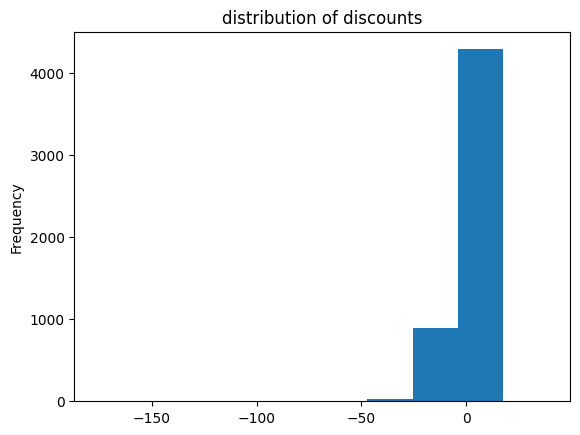

In [13]:
#identify spoilage transactions (all 100% discounted)
df.query("`Discount and Rewards` != 0")['Discount and Rewards'].plot(kind = 'hist', bins = 10, title='distribution of discounts')

In [14]:
#attempt to value all positive value carts
sales_sum_df_pos = df.groupby(['order_dt','Order ID']).agg(sales_sum=('Sales','sum')).query('sales_sum >0').reset_index()

In [16]:
agg_sales_trans = sales_sum_df_pos.groupby([sales_sum_df_pos['order_dt'].dt.normalize()]).agg(avg_basket=('sales_sum','mean'),num_trans=('Order ID','nunique')).reset_index()

<Axes: title={'center': 'Average Basket Value Over Time'}, xlabel='order_dt'>

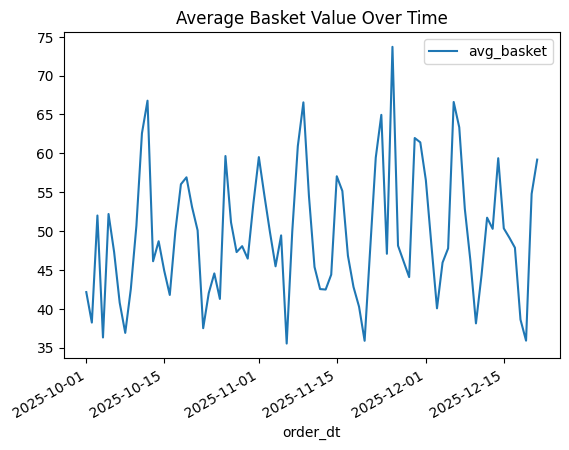

In [17]:
#time series of average basket value by order_dt
agg_sales_trans.plot(kind='line', x='order_dt', y='avg_basket', title='Average Basket Value Over Time')

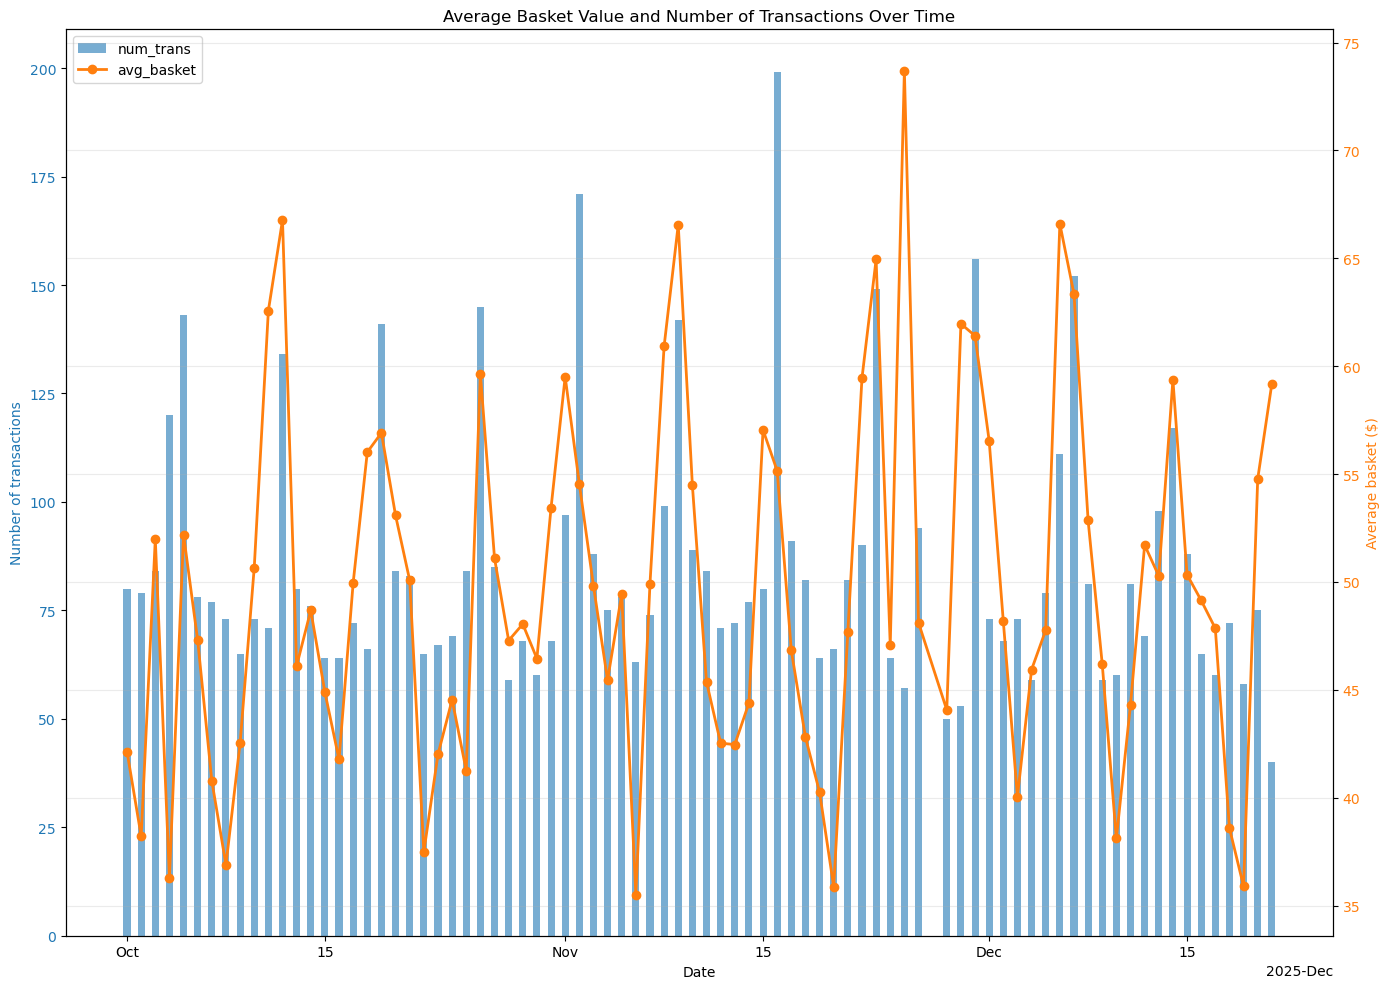

In [25]:
import matplotlib.dates as mdates

# ensure agg_sales_trans exists and order_dt is datetime
agg_sales_trans['order_dt'] = pd.to_datetime(agg_sales_trans['order_dt'])

fig, ax1 = plt.subplots(figsize=(14,10))

# bar plot: number of transactions (vertical bars)
ax1.bar(agg_sales_trans['order_dt'], agg_sales_trans['num_trans'],
        width=0.5, alpha=0.6, color='C0', label='num_trans')
ax1.set_ylabel('Number of transactions', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# format x-axis nicely for dates
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax1.xaxis.get_major_locator()))
ax1.set_xlabel('Date')

# line plot on secondary y-axis: average basket value
ax2 = ax1.twinx()
ax2.plot(agg_sales_trans['order_dt'], agg_sales_trans['avg_basket'],
         marker='o', color='C1', linewidth=2, label='avg_basket')
ax2.set_ylabel('Average basket ($)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

# combined legend and layout
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.title('Average Basket Value and Number of Transactions Over Time')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Recreate the above plot but partition by day of week, as there appears to be strong seasonality

In [18]:
cols = ['Barcode','Brand','Department','Items Total','Order Date',
'Product ID','Quantity','Sub-Department','Order ID']
df2 = df.loc[:,cols]
df2.columns = [i.replace(' ','_').lower() for i in cols]

In [19]:
#df2['order_date'].to_dateteime(format="%a",%M %d, %Y, %h:%m %p)
try:
    df2['order_date2'] = pd.to_datetime(df2['order_date'],errors='coerce')
except ValueError as e:
    print(e)

/var/folders/7x/md6t50l11gnfjmmrc6f2f7lr0000gn/T/ipykernel_82216/3822103420.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['order_date2'] = pd.to_datetime(df2['order_date'],errors='coerce')


In [20]:
first = df2.groupby([df2['order_date2'].dt.normalize()])['order_id'].nunique().reset_index()


In [22]:
#measure the average number of carts by day of week and month-year
first_gb = first.groupby([first['order_date2'].dt.month,first['order_date2'].dt.dayofweek])['order_id'].mean()
first_gb.index.names = ['month', 'dayofweek']
first_gb = first_gb.reset_index()

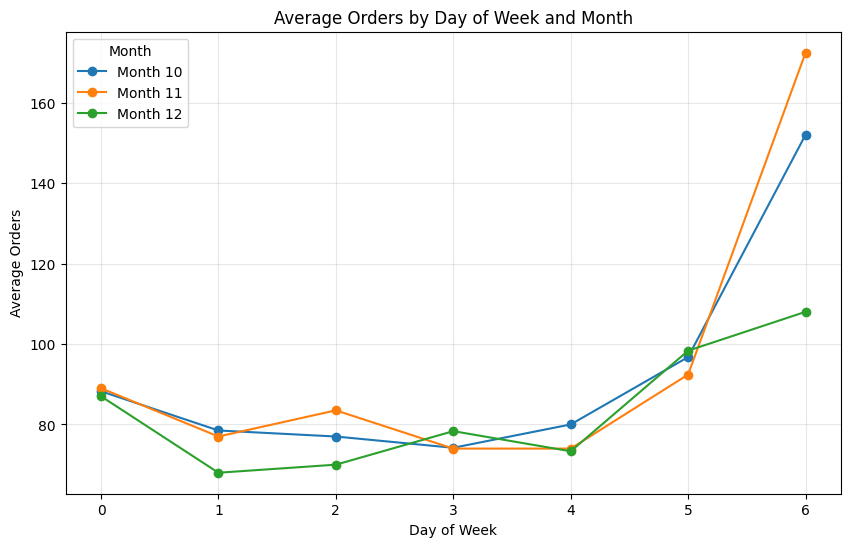

In [23]:
pivot_data = first_gb.pivot(index='dayofweek', columns='month', values='order_id')

plt.figure(figsize=(10, 6))
pivot_data.plot(ax=plt.gca(), marker='o')

plt.xlabel('Day of Week')
plt.ylabel('Average Orders')
plt.title('Average Orders by Day of Week and Month')
plt.legend(title='Month', labels=[f'Month {int(m)}' for m in pivot_data.columns])
plt.grid(True, alpha=0.3)
plt.show()

## Barcode level analysis

- **correlation** between barcodes and # of carts per week: to determine "habituation", ie should a customer come in to buy a a barcode does that drive more visits? The more visits that include that item, the more habituation. I wonder if I can build a correlation chart? I need to look into the formula
- **correlation** between barcodes and value of cart
- *"reach"*: given the presence of a barcode, how many other categories are purchased/included in cart

In [24]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import cart_analysis_package.df_transforms as df_transforms
from importlib import reload

In [25]:
reload(df_transforms)

<module 'cart_analysis_package.df_transforms' from '/Users/casita/Documents/gitdev/merchAnalysis/cart_analysis/cart_analysis_package/df_transforms.py'>

Scrub the dataframe and return only non-negative sales order_id

In [29]:
#df = pd.read_csv('./Items with cost(2).csv')
df = pd.read_csv('./data/1Q26_orders.csv')
#./data/1Q26_orders.csv
df = df_transforms.clean_df2(df)
df = df_transforms.remove_negative(df)
df = df_transforms.subset_shopping2(df)

/var/folders/7x/md6t50l11gnfjmmrc6f2f7lr0000gn/T/ipykernel_2404/3821213451.py:2: DtypeWarning: Columns (0: Brand, 1: Barcode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/1Q26_orders.csv')
/Users/casita/Documents/gitdev/merchAnalysis/cart_analysis/cart_analysis_package/df_transforms.py:78: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')


## Analytical approach from 5/17
- proportion of total orders having sub_dept (requires counting unique `order_ids` over measurement period, then counting unique `order_id` having the sub_dept)
- "repertoire": (#of other subs|appearance of sub_dept in cart)
- cart value relationships: (distribution of cart value|appearance of sub_dept in cart) 

Experimenting with two different grouping-aggregating approaches:
1. `order_id` lens
2. `sub-department` lens

Set out to get proportion of orders for each **day** that include a *sub_department* 


In [ ]:
#df = df.assign(order_date=df['order_date'].dt.date)
#make a list of unique sub_dept and place in a series

df_list_sub = df.groupby(['order_id','order_date_str'])['sub_department'].unique().reset_index()

#it might be easier to cut this dataframe from the opposite perspective: # of order_ids by date grouping by sub-department
df_order_by_sub_date = df.groupby(['sub_department','order_date_str'])['order_id'].nunique().reset_index()

df_order_by_dep_date = df.groupby(['department','order_date_str'])['order_id'].nunique().reset_index()

#context/level-of-detail challenge: consider the # of unique order_id by order_date
df_orders_by_date = df.groupby('order_date_str')['order_id'].nunique().reset_index()

df_final_sub = df_order_by_sub_date.merge(df_orders_by_date, on='order_date_str', how='left')

df_final_dept = df_order_by_dep_date.merge(df_orders_by_date, on='order_date_str', how='left')

#rename on sub-dept lens
df_final_sub.rename(columns={'order_id_x':'num_orders_for_sub','order_id_y':'num_orders_date'}, inplace=True)

#rename on dept lens
df_final_dept.rename(columns={'order_id_x':'num_orders_for_dept','order_id_y':'num_orders_date'}, inplace=True)



In [ ]:

#daily values contain a lot of noise; aggregate by WEEK instead; will use duckdb here because date manipulation is bad using python
import duckdb as ddb
con = ddb.connect()
con.register("df", df)
df2 = con.execute(
"""
SELECT 
week, 
list_unique(flatten(list(dept_wk_order_ids))) as week_orders_all, 
map_from_entries(list(struct_pack(k := department, v := len(dept_wk_order_ids)))) AS dept_week_orders
FROM (
    SELECT date_trunc('week',order_date_str) as week, department, 
    array_agg(distinct order_id) as dept_wk_order_ids
    FROM df
    GROUP BY 1,2
) as t
GROUP BY 1
""").df()

In [12]:
#add prop field
df_final_dept = df_final_dept.assign(prop_orders = df_final_dept['num_orders_for_dept']/df_final_dept['num_orders_date'])
df_final_sub = df_final_sub.assign(prop_orders = df_final_sub['num_orders_for_sub']/df_final_sub['num_orders_date'])

In [5]:
#QA pick a day and sort the dept and sub-dept by proportion of days' orders

feb_ten_sub = df_final_sub.loc[df_final_sub['order_date_str'] == datetime.datetime.strptime('2026-02-01', '%Y-%m-%d').date(),:].assign(prop_orders = df_final_sub['num_orders_for_sub']/df_final_sub['num_orders_date'])

feb_ten_dept = df_final_dept.loc[df_final_dept['order_date_str'] == datetime.datetime.strptime('2026-02-01', '%Y-%m-%d').date(),:].assign(prop_orders = df_final_dept['num_orders_for_dept']/df_final_dept['num_orders_date'])

In [17]:
target_date = datetime.date(2026, 1, 3)
display(df.query("department == 'ALCOHOLIC BEVERAGES' and order_date_str == @target_date").sort_values('order_id'))
display(df_final_dept.query("department == 'ALCOHOLIC BEVERAGES' and order_date_str == @target_date"))
#df.query('department == "ALCOHOLIC BEVERAGES"')

,barcode,brand,department,items_amount,order_date,product_name_id,quantity,sub_department,order_id,sales,order_date_str
6773,632726047900,NaN,ALCOHOLIC BEVERAGES,17.28,2026-01-03 17:37:00,"Beer, Wavetable IPA, 16oz, Grimm Ales - 5710385",4.0,Beer,GHA1767479821,17.28,2026-01-03
6065,850003883274,Bronx Brewery,ALCOHOLIC BEVERAGES,17.20,2026-01-03 18:00:00,"Beer, Bronx Brewery, World Gone Hazy IPA, Per ...",4.0,Beer,GHA1767481243,17.20,2026-01-03
6480,704260804100,NaN,ALCOHOLIC BEVERAGES,10.58,2026-01-03 18:00:00,"Beer, Mummy Dust IPA, 16oz, Wild East - 31759501",2.0,Beer,GHA1767481243,10.58,2026-01-03
6202,860013218164,NaN,ALCOHOLIC BEVERAGES,2.51,2026-01-03 15:39:00,"Beer, Eastern Gold, 12oz, Drowned Lands - 1436861",1.0,Beer,GHB1767472742,2.51,2026-01-03
6708,198715837018,Threes Brewing,ALCOHOLIC BEVERAGES,2.69,2026-01-03 15:39:00,"Beer, Vliet Pilsner, 12oz, Threes Brewing - 31...",1.0,Beer,GHB1767472742,2.69,2026-01-03


,department,order_date_str,num_orders_for_dept,num_orders_date
0,ALCOHOLIC BEVERAGES,2026-01-03,3,84


In [28]:
df_final_dept.loc[(df_final_dept['order_date_str'] == datetime.datetime.strptime('2026-04-20', '%Y-%m-%d').date()) & (df_final_dept['department'] == 'SUPPLEMENTS'),:]

,department,order_date_str,num_orders_for_dept,num_orders_date,prop_orders
1692,SUPPLEMENTS,2026-04-20,1,132,0.007576


First graphic: plot the proportions by department by day. This displays how many (as a %) of each day's carts contain an item in the department.

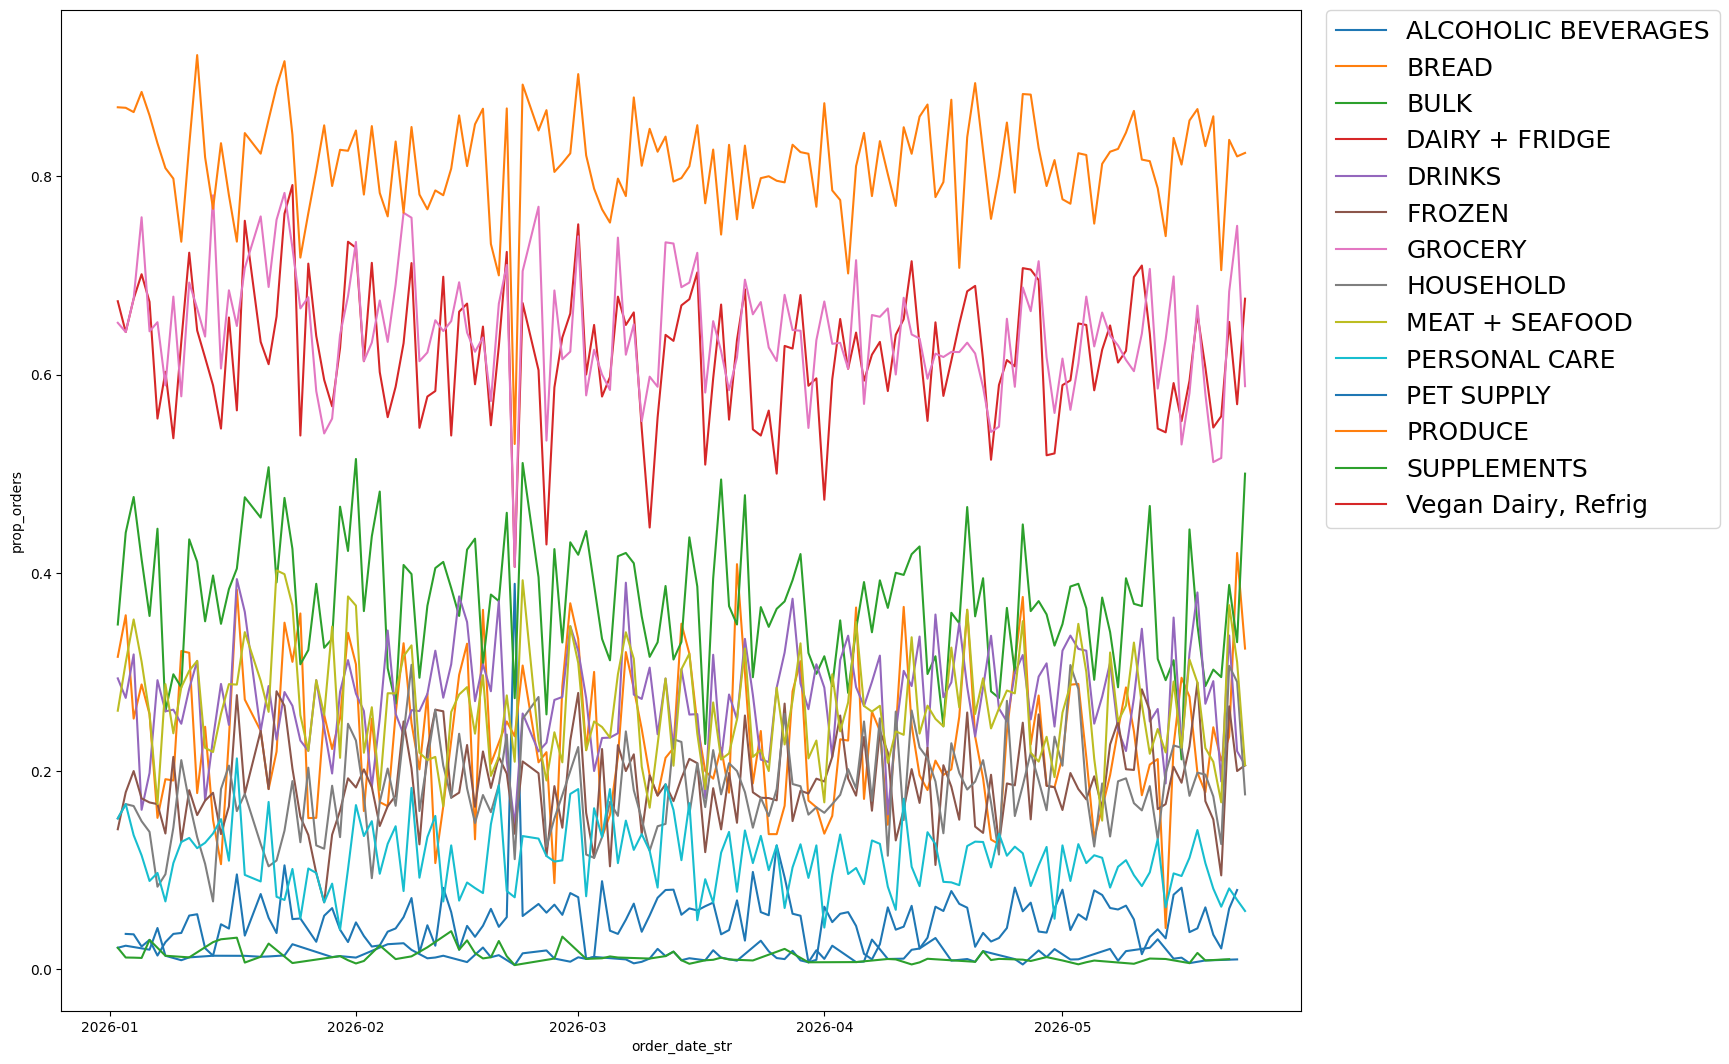

In [13]:
plt.figure(figsize=(16, 13))
sns.lineplot(x='order_date_str', y='prop_orders', data=df_final_dept, hue='department',palette=sns.color_palette('tab10',df_final_dept['department'].nunique()))
plt.legend(bbox_to_anchor=(1.02, 1), fontsize='18', loc='upper left', borderaxespad=0)
#plt.legend(title='Team', fontsize='10', title_fontsize='14')

In [ ]:
### Upload an analytics table to the droplet-hosted database

df_final_dept



In order to be able to use port forwarding, I have to set up an ssh connection to Radish on my terminal beforehand via an ssh command (NOTE I don't need to use Tailscale): <br>
>ssh -4 -L 127.0.0.1:5433:localhost:3306 lcalleja@67.207.80.236

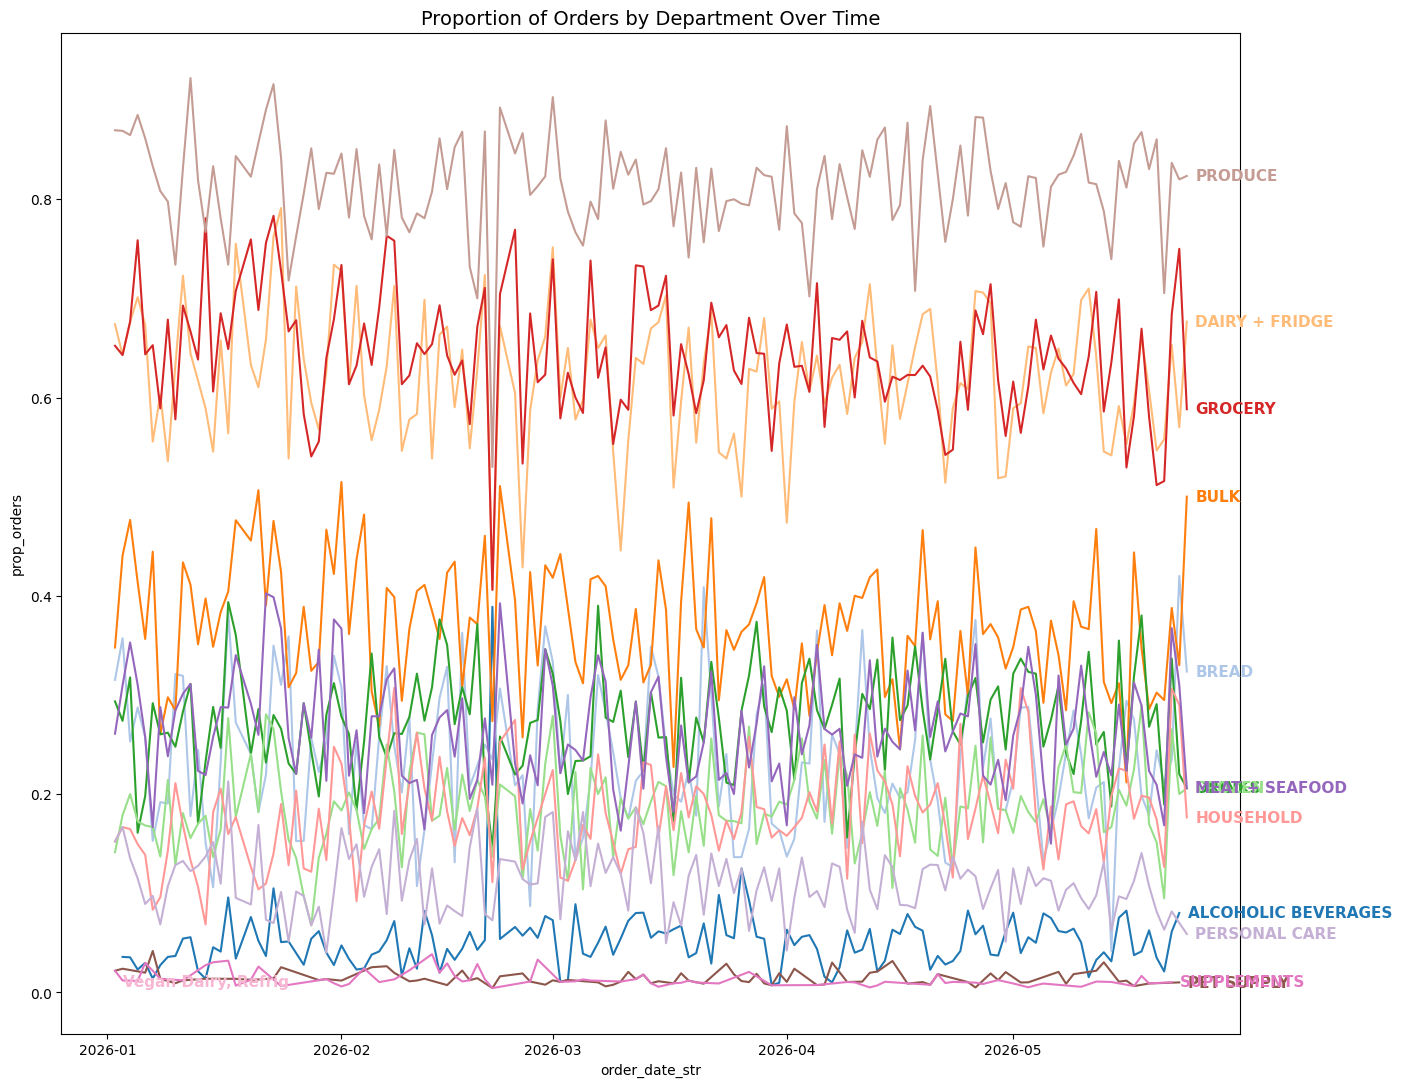

In [14]:
fig, ax = plt.subplots(figsize=(18, 13))
palette = sns.color_palette('tab20', df_final_dept['department'].nunique())

sns.lineplot(
    x='order_date_str', y='prop_orders',
    data=df_final_dept, hue='department',
    palette=palette, ax=ax
)

# ── capture labels BEFORE removing the legend ──────────────────────────
handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()

# build color → dept name map (round to avoid float precision mismatches)
import matplotlib.colors as mcolors
def rgb_key(c):
    return tuple(round(v, 4) for v in mcolors.to_rgba(c)[:3])

color_label = {rgb_key(h.get_color()): lbl for h, lbl in zip(handles, labels)}

# ── annotate each line at its last valid point ──────────────────────────
for line in ax.get_lines():
    xd, yd = line.get_xdata(), line.get_ydata()
    if len(xd) == 0:
        continue
    last_i = next((i for i in range(len(yd) - 1, -1, -1) if not np.isnan(yd[i])), None)
    if last_i is None:
        continue
    dept_name = color_label.get(rgb_key(line.get_color()))
    if dept_name is None:          # skip any non-department lines
        continue
    ax.annotate(
        dept_name,
        xy=(xd[last_i], yd[last_i]),
        xytext=(6, 0),
        textcoords='offset points',
        va='center', ha='left',
        color=line.get_color(),
        fontsize=11, fontweight='bold',
        clip_on=False
    )

fig.subplots_adjust(right=0.78)
plt.title('Proportion of Orders by Department Over Time', fontsize=14)
plt.show()

## Average value of cart containing item in department/sub-department
### sub-study: # of items in cart when an item in dept/sub-dept appears
### does the value of the cart increase or decrease as the # of items in the dept/sub-dept vary

### Level of detail challenge: 
1. Get average # of items in all carts by order_date_str for each department
*could be better served by using duckdb*

In [16]:
import duckdb as ddb
con = ddb.connect()
con.register("df", df)
'''
df = df_transforms.clean_df2(df)
df = df_transforms.remove_negative(df)
df = df_transforms.subset_shopping2(df)
'''

df2 = con.execute(
"""
SELECT order_id, order_date_str, unnest(dept_array) dept, order_sales, order_quantity, cnt_unq_dept
FROM (
    SELECT order_id, order_date_str, array_agg(DISTINCT department) dept_array, 
    SUM(sales) AS order_sales, count(distinct department) AS cnt_unq_dept,SUM(quantity) AS order_quantity
    FROM df
    GROUP BY 1,2
) as t
""").df()


#look at a monthly avg of cart value by department (ie if the department appears in the cart, what is the average cart sales value)
con.register("df2", df2)

df3 = con.execute("""
select date_trunc('month',order_date_str) as month, dept, avg(order_sales) as avg_cart_sales, avg(order_quantity) as avg_cart_quantity
from df2
group by 1,2
order by 1,2
""").df()

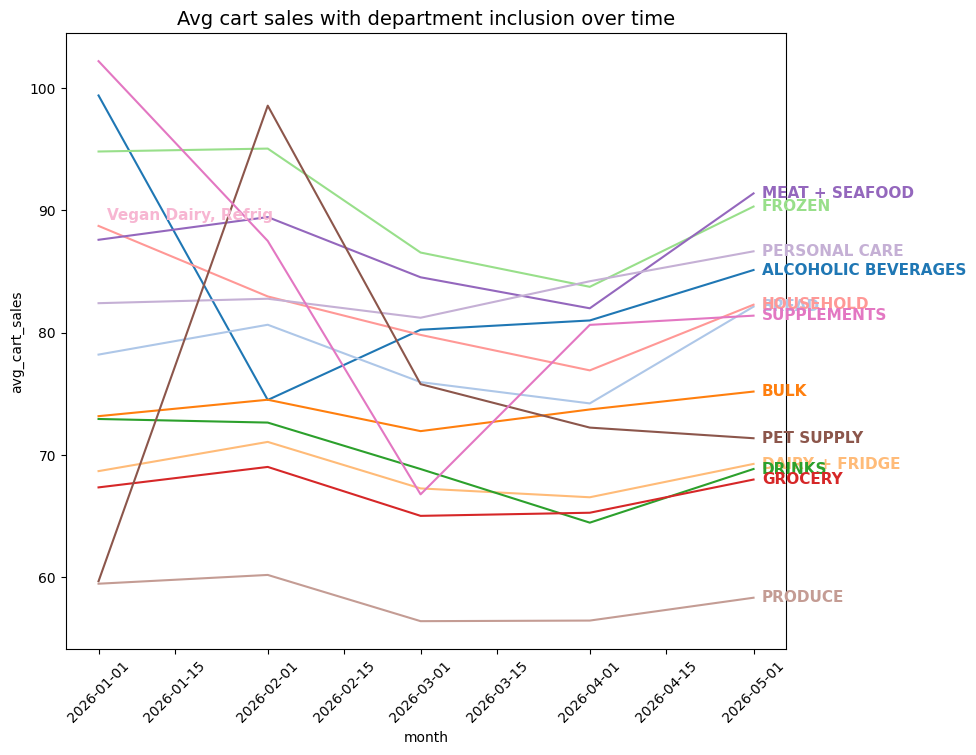

In [23]:
fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette('tab20', df3['dept'].nunique())

sns.lineplot(
    x='month', y='avg_cart_sales',
    data=df3, hue='dept',
    palette=palette, ax=ax
)
ax.tick_params(axis='x', labelrotation=45)

# ── capture labels BEFORE removing the legend ──────────────────────────
handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()

# build color → dept name map (round to avoid float precision mismatches)
import matplotlib.colors as mcolors
def rgb_key(c):
    return tuple(round(v, 4) for v in mcolors.to_rgba(c)[:3])

color_label = {rgb_key(h.get_color()): lbl for h, lbl in zip(handles, labels)}

# ── annotate each line at its last valid point ──────────────────────────
for line in ax.get_lines():
    xd, yd = line.get_xdata(), line.get_ydata()
    if len(xd) == 0:
        continue
    last_i = next((i for i in range(len(yd) - 1, -1, -1) if not np.isnan(yd[i])), None)
    if last_i is None:
        continue
    dept_name = color_label.get(rgb_key(line.get_color()))
    if dept_name is None:          # skip any non-department lines
        continue
    ax.annotate(
        dept_name,
        xy=(xd[last_i], yd[last_i]),
        xytext=(6, 0),
        textcoords='offset points',
        va='center', ha='left',
        color=line.get_color(),
        fontsize=11, fontweight='bold',
        clip_on=False
    )

fig.subplots_adjust(right=0.78)
plt.title('Avg cart sales with department inclusion over time', fontsize=14)
plt.show()    

<Axes: xlabel='month', ylabel='avg_cart_sales'>

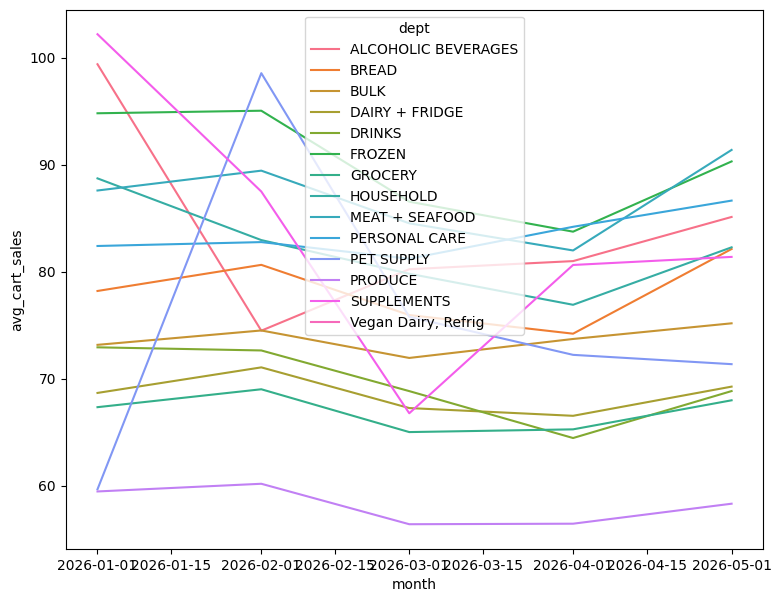

In [18]:
plt.figure(figsize=(9, 7))
#sns.lineplot(x='order_date_str', y='prop_orders', data=df_final_dept, hue='department',palette=sns.color_palette('tab10',df_final_dept['department'].nunique()))
sns.lineplot(x='month',y='avg_cart_sales',data=df3,hue='dept')

The plot of department:cart value is a little hard to follow, but demonstrates that there is some pronounced value differences between some departments, with an almost $40 range between some. There is some interchange between rank/position as the year wears on indicating that seasonality could be a factor.

### Repertoire: Similarly, count the avg # of items in the cart when a product from that dept is in the cart.

In [14]:
display(df2)

,order_id,order_date_str,dept,order_sales,order_quantity,cnt_unq_dept
0,GHA1777060795,2026-04-24,DAIRY + FRIDGE,103.19,22.0,4
1,GHA1777060795,2026-04-24,GROCERY,103.19,22.0,4
2,GHA1777060795,2026-04-24,HOUSEHOLD,103.19,22.0,4
3,GHA1777060795,2026-04-24,PRODUCE,103.19,22.0,4
4,GHA1777124126,2026-04-25,PRODUCE,0.00,18.0,1
...,...,...,...,...,...,...
58333,GHA1776020798,2026-04-12,PRODUCE,0.00,1.0,1
58334,GHA1767659652,2026-01-05,PRODUCE,1.65,1.0,1
58335,GHA1769710173,2026-01-29,PRODUCE,0.50,1.0,1
58336,GHA1774820878,2026-03-29,PRODUCE,0.00,1.0,1


In [19]:
con.register("df2", df2)

df4 = con.execute("""
select date_trunc('month',order_date_str) as month, dept, avg(cnt_unq_dept) as avg_repertoire
from df2
group by 1,2
order by 1,2
""").df()

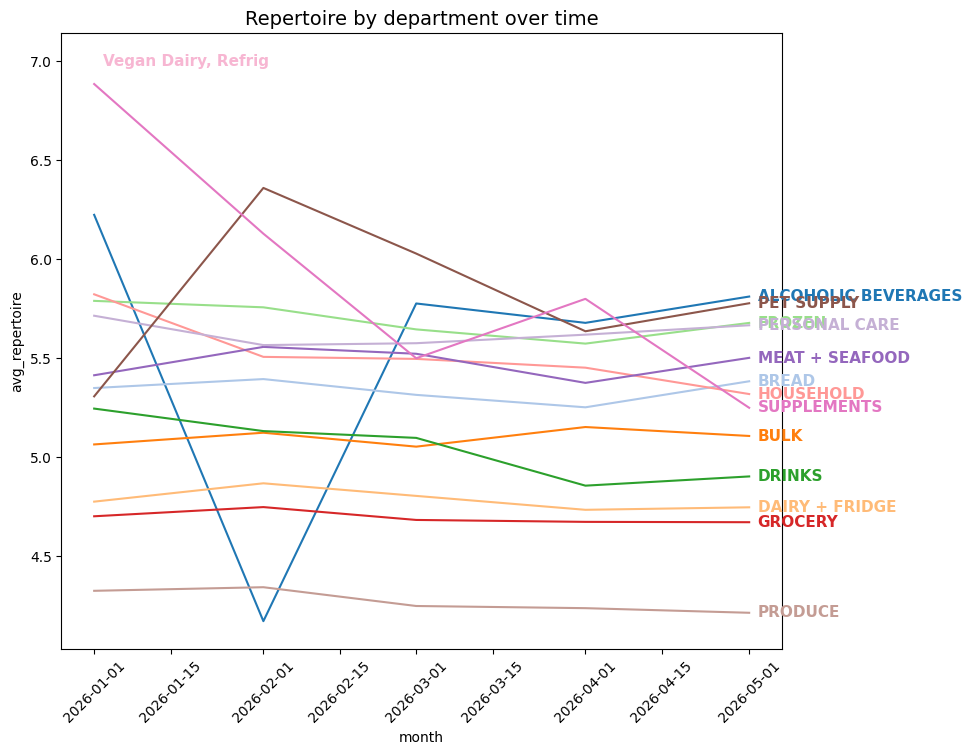

In [24]:
fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette('tab20', df4['dept'].nunique())

sns.lineplot(
    x='month', y='avg_repertoire',
    data=df4, hue='dept',
    palette=palette, ax=ax
)

ax.tick_params(axis='x', labelrotation=45)

# ── capture labels BEFORE removing the legend ──────────────────────────
handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()

# build color → dept name map (round to avoid float precision mismatches)
import matplotlib.colors as mcolors
def rgb_key(c):
    return tuple(round(v, 4) for v in mcolors.to_rgba(c)[:3])

color_label = {rgb_key(h.get_color()): lbl for h, lbl in zip(handles, labels)}

# ── annotate each line at its last valid point ──────────────────────────
for line in ax.get_lines():
    xd, yd = line.get_xdata(), line.get_ydata()
    if len(xd) == 0:
        continue
    last_i = next((i for i in range(len(yd) - 1, -1, -1) if not np.isnan(yd[i])), None)
    if last_i is None:
        continue
    dept_name = color_label.get(rgb_key(line.get_color()))
    if dept_name is None:          # skip any non-department lines
        continue
    ax.annotate(
        dept_name,
        xy=(xd[last_i], yd[last_i]),
        xytext=(6, 0),
        textcoords='offset points',
        va='center', ha='left',
        color=line.get_color(),
        fontsize=11, fontweight='bold',
        clip_on=False
    )

fig.subplots_adjust(right=0.78)
plt.title('Repertoire by department over time', fontsize=14)
plt.show()    

## Association Rules
### Apriori analysis: support, confidence, lift

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import cart_analysis_package.df_transforms as df_transforms
from importlib import reload
from mlxtend.preprocessing import TransactionEncoder

df = pd.read_csv('./data/1Q26_orders.csv')
#./data/1Q26_orders.csv
df = df_transforms.clean_df2(df)
df = df_transforms.remove_negative(df)
df = df_transforms.subset_shopping2(df)

#create a list of lists of the depts in each order_id/basket
test = df_transforms.encoding(df,'dept_list')
test_list = test['dept_list'].to_list()
print(len(test_list))

te = TransactionEncoder()
te_array = te.fit(test_list).transform(test_list)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)


/var/folders/7x/md6t50l11gnfjmmrc6f2f7lr0000gn/T/ipykernel_2561/3484217704.py:11: DtypeWarning: Columns (0: Brand, 1: Barcode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/1Q26_orders.csv')
/Users/casita/Documents/gitdev/merchAnalysis/cart_analysis/cart_analysis_package/df_transforms.py:78: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')


15307


Sort the orders dataframe by Support on the condition that the itemset be a minimum of length 2

In [4]:
from mlxtend.frequent_patterns import apriori
#find use cases: https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/
#support is a parameter; formula: transactions_where_item(s)_occur / total_transactions
#apriori() returns a pd.DataFrame
#Each itemset in the 'itemsets' column is of type frozenset, which is a Python built-in type that behaves similarly to sets except that it is immutable
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True)
frequent_itemsets.sort_values(by='support', ascending=False, inplace=True)
#remove itemsets of len <2
#print("Total Frequent Itemsets:", frequent_itemsets.shape[0])
frequent_itemsets.loc[frequent_itemsets['itemsets'].apply(len)>1,].sort_values(by='support', ascending = False).head()
#display(frequent_itemsets.head())

,support,itemsets
33,0.569282,"frozenset({DAIRY + FRIDGE, PRODUCE})"
45,0.564709,"frozenset({GROCERY, PRODUCE})"
29,0.477559,"frozenset({DAIRY + FRIDGE, GROCERY})"
95,0.450121,"frozenset({DAIRY + FRIDGE, GROCERY, PRODUCE})"
26,0.341674,"frozenset({BULK, PRODUCE})"


In [ ]:
#get a sense of the distributuion of the itemset sizes
frequent_itemsets['itemsets'].apply(lambda x: len(x)).value_counts()

itemsets
3    65
4    46
2    39
5    12
1    11
Name: count, dtype: int64

In [14]:
#following along examples from https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/association_rules/#example-2-rule-generation-and-selection-criteria

from mlxtend.frequent_patterns import apriori, fpmax, fpgrowth


te = TransactionEncoder()
te_ary = te.fit(test_list).transform(test_list)
df = pd.DataFrame(te_ary, columns=te.columns_)
frequent_itemsets = fpgrowth(df, min_support=0.05, use_colnames=True)
len(frequent_itemsets)

173

In [17]:
df.head()

,ALCOHOLIC BEVERAGES,BREAD,BULK,DAIRY + FRIDGE,DRINKS,FROZEN,GROCERY,HOUSEHOLD,MEAT + SEAFOOD,PERSONAL CARE,PET SUPPLY,PRODUCE,SUPPLEMENTS,"Vegan Dairy, Refrig"
0,False,False,True,True,False,False,False,False,False,False,False,True,False,False
1,False,True,True,True,False,False,True,True,True,False,False,True,False,False
2,False,False,True,True,False,False,True,False,False,False,False,True,False,False
3,False,False,True,True,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,True,False,False,False,False,False,True,False,False


In [15]:
from mlxtend.frequent_patterns import association_rules

association_rules(frequent_itemsets, metric="support", min_threshold=0.05, num_itemsets=len(df.index))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({DAIRY + FRIDGE}),frozenset({PRODUCE}),0.626380,0.815444,0.569282,0.908844,1.114539,1.0,0.058504,2.024627,0.275061,0.652441,0.506082,0.803485
1,frozenset({PRODUCE}),frozenset({DAIRY + FRIDGE}),0.815444,0.626380,0.569282,0.698125,1.114539,1.0,0.058504,1.237666,0.556841,0.652441,0.192027,0.803485
2,frozenset({DAIRY + FRIDGE}),frozenset({GROCERY}),0.626380,0.642843,0.477559,0.762411,1.185999,1.0,0.074895,1.503257,0.419755,0.603235,0.334778,0.752649
3,frozenset({GROCERY}),frozenset({DAIRY + FRIDGE}),0.642843,0.626380,0.477559,0.742886,1.185999,1.0,0.074895,1.453130,0.439104,0.603235,0.311831,0.752649
4,"frozenset({DAIRY + FRIDGE, PRODUCE})",frozenset({GROCERY}),0.569282,0.642843,0.450121,0.790682,1.229976,1.0,0.084162,1.706286,0.434103,0.590706,0.413932,0.745442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,"frozenset({BULK, PRODUCE})",frozenset({PERSONAL CARE}),0.341674,0.112628,0.051349,0.150287,1.334362,1.0,0.012867,1.044319,0.380629,0.127432,0.042438,0.303102
1468,"frozenset({PERSONAL CARE, PRODUCE})",frozenset({BULK}),0.097080,0.374796,0.051349,0.528937,1.411266,1.0,0.014964,1.327219,0.322749,0.122107,0.246545,0.332971
1469,frozenset({BULK}),"frozenset({PERSONAL CARE, PRODUCE})",0.374796,0.097080,0.051349,0.137005,1.411266,1.0,0.014964,1.046264,0.466114,0.122107,0.044218,0.332971
1470,frozenset({PERSONAL CARE}),"frozenset({BULK, PRODUCE})",0.112628,0.341674,0.051349,0.455916,1.334362,1.0,0.012867,1.209973,0.282382,0.127432,0.173535,0.303102


In [ ]:
from mlxtend.frequent_patterns import association_rules
#metric can be support, confidence or lift
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
rules = rules[rules['antecedents'].apply(lambda x: len(x) >= 1) & rules['consequents'].apply(lambda x: len(x) >= 1)]
print("Association Rules:", rules.shape[0])
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

Association Rules: 1383
                   antecedents                  consequents   support  \
0            frozenset({BULK})           frozenset({BREAD})  0.114392   
1           frozenset({BREAD})            frozenset({BULK})  0.114392   
2           frozenset({BREAD})  frozenset({DAIRY + FRIDGE})  0.193572   
3  frozenset({DAIRY + FRIDGE})           frozenset({BREAD})  0.193572   
4          frozenset({DRINKS})           frozenset({BREAD})  0.074802   

   confidence      lift  
0    0.305212  1.257233  
1    0.471206  1.257233  
2    0.797363  1.272970  
3    0.309032  1.272970  
4    0.269920  1.111858  


In [38]:
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
rules = rules[rules['antecedents'].apply(lambda x: len(x) >= 1) & rules['consequents'].apply(lambda x: len(x) >= 1)]
print("Association Rules:", rules.shape[0])
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

Association Rules: 1383
                   antecedents                  consequents   support  \
0            frozenset({BULK})           frozenset({BREAD})  0.114392   
1           frozenset({BREAD})            frozenset({BULK})  0.114392   
2           frozenset({BREAD})  frozenset({DAIRY + FRIDGE})  0.193572   
3  frozenset({DAIRY + FRIDGE})           frozenset({BREAD})  0.193572   
4          frozenset({DRINKS})           frozenset({BREAD})  0.074802   

   confidence      lift  
0    0.305212  1.257233  
1    0.471206  1.257233  
2    0.797363  1.272970  
3    0.309032  1.272970  
4    0.269920  1.111858  


### Per order_id calculate:
- total value
- number of total items
- number of items per sub-department
- list of unique sub-department

In [3]:
#context challenges (aka level of detail)
# order_id total
# sub-department item count

sub_data = df.groupby(['order_id','sub-department']).agg(
    sub_dept_distinct_products=('sub-department','count'), #think I can get away with this bc Vori rolls up items to barcode @ the register
    sub_dep_total_item_cnt=('quantity','sum')
)

order_level_sales = df.groupby('order_id').agg(
    total_sales_order=('sales','sum')).query('total_sales_order>0')

#df.groupby(['order_id','sub-department']).agg

In [38]:
df['sub-department'][df['sub-department'].str.contains('Snacks')].unique()

<StringArray>
['Snacks, Bulk', 'Snacks, Shelf Stable']
Length: 2, dtype: str